In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Get Data

In [2]:
df = pd.read_csv("C:/Users/Abhineet/Documents/LEPSUCD/log12.csv")
ppg = df[['IR', 'RED']].to_numpy()

rd = ppg[:, 1] # RED
ir = ppg[:, 0] # IR

In [3]:
%matplotlib widget

## Plot Data

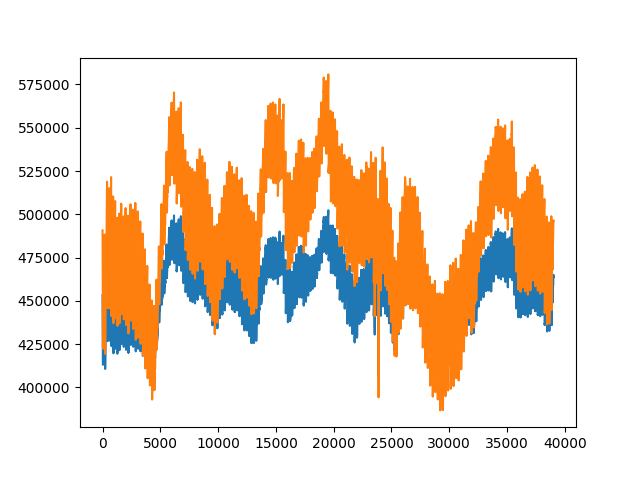

In [4]:
plt.figure()
plt.plot(rd)
plt.plot(ir)

## Data Setup

In [11]:
temp_rd = []
temp_ir = []
plot_indices = [1]
heart_rate = []
spo2 = []
SF_spo2 = 25
BUFFER_SIZE = SF_spo2 * 4

for i in range(len(rd)):
    if (i % 20) == 0:
        temp_rd.append(rd[i])
        temp_ir.append(ir[i])

# Make array sizes divisible by 100 (original size was 1951)
temp_rd = temp_rd[:1900]
temp_ir = temp_ir[:1900]

# Split signal into 100-size chunks
rd_buffs = np.split(np.asarray(temp_rd), 19)
ir_buffs = np.split(np.asarray(temp_ir), 19)

## Peak Detector

In [6]:
def find_peak_above(peak_locs, an_x, size, min_height, max_num_peaks) -> int:
    i = 1
    width = 0
    num_peaks = 0

    while (i < size - 1):
        if (an_x[i] > min_height and an_x[i] > an_x[i - 1]): # find left edge of potential peaks
            width = 1

            while (i + width < size and an_x[i] == an_x[i + width]): # find flat peaks
                width += 1
            
            if (an_x[i] > an_x[i + width] and num_peaks < max_num_peaks): # find right edge of peaks
                peak_locs[num_peaks] = i
                num_peaks += 1
                i += width + 1
            else:
                i += width
        else:
            i += 1
    
    return num_peaks

def sort_peaks_descending(an_x, peak_locs, size):
    peak_locs = np.int_(peak_locs)
    temp = 0

    for i in range(size):
        temp = peak_locs[i]

        j = i
        while (j > 0 and an_x[temp] > an_x[peak_locs[j - 1]]):
            peak_locs[j] = peak_locs[j - 1]
            j -= 1
        
        peak_locs[j] = temp

def remove_close_peaks(peak_locs: np.ndarray, an_x, num_peaks, min_distance) -> int:
    old_num_peaks = 0
    dist = 0
    sort_peaks_descending(an_x, peak_locs, num_peaks) # sort peaks from large to small

    i = -1
    while (i < num_peaks):
        old_num_peaks = num_peaks
        num_peaks = i + 1

        for j in range(i + 1, old_num_peaks):
            dist = peak_locs[j] - (-1 if i == -1 else peak_locs[i])
            if (abs(dist) > min_distance):
                peak_locs[num_peaks] = peak_locs[j]
                num_peaks += 1
        
        i += 1
    
    peak_locs.sort() # re-sort in ascending order
    return num_peaks

def find_peaks(peak_locs, an_x, size, min_height, min_distance, max_num_peaks) -> int:
    num_peaks = find_peak_above(peak_locs, an_x, size, min_height, max_num_peaks)
    num_peaks = remove_close_peaks(peak_locs, an_x, num_peaks, min_distance)
    return num_peaks

## SpO2 Calculation Algorithm

C:\Users\Abhineet\AppData\Local\Temp\ipykernel_14036\3856693677.py:27: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()
C:\Users\Abhineet\AppData\Local\Temp\ipykernel_14036\3856693677.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  heart_rate.append(int((SF_spo2 * 60)) / peak_interval_sum)


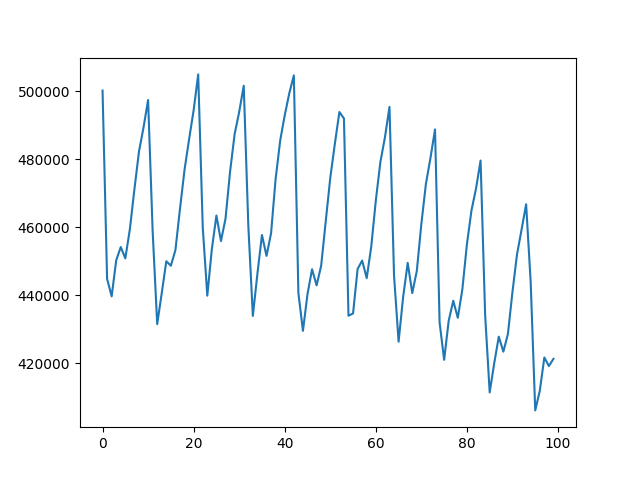

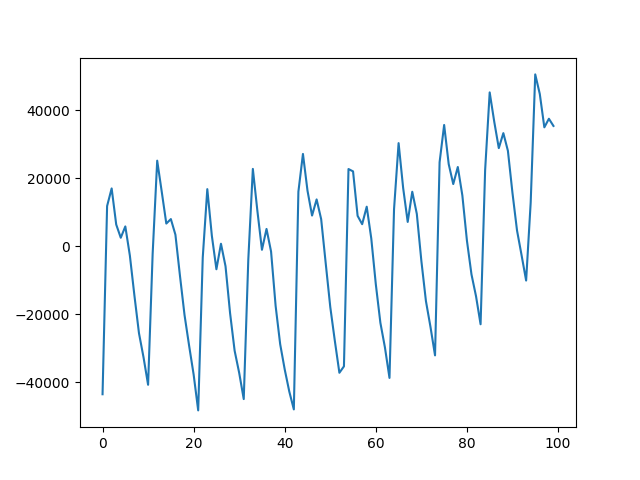

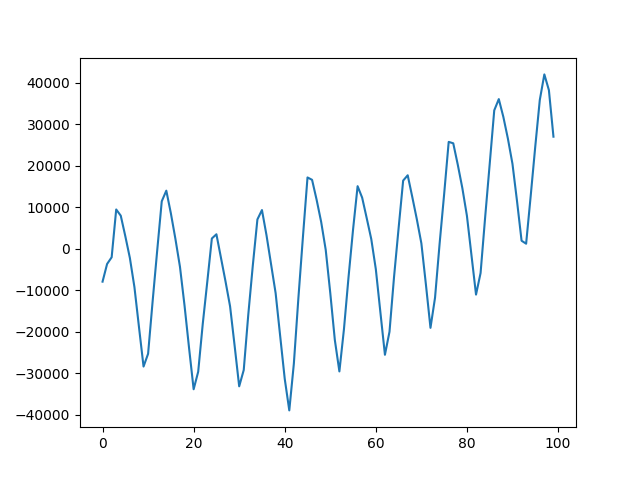

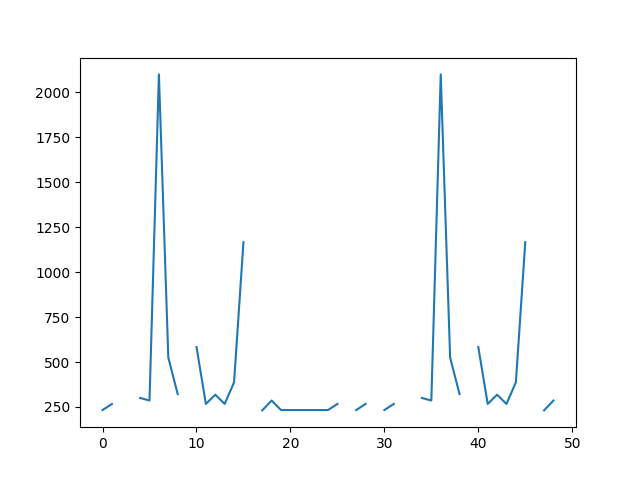

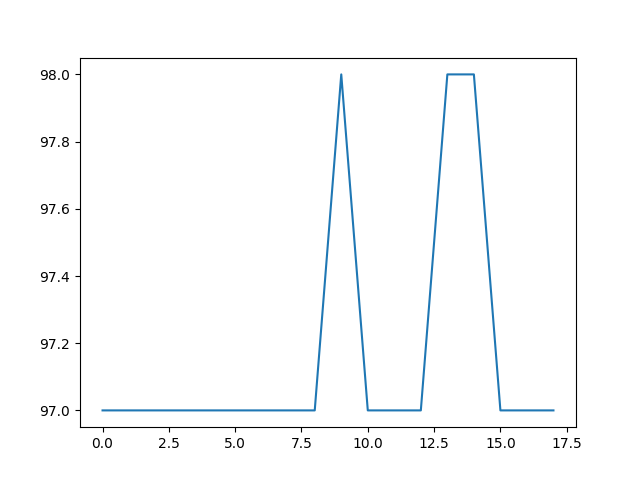

In [20]:
uch_spo2_table = [95, 95, 95, 96, 96, 96, 97, 97, 97, 97, 97, 98, 98, 98, 98, 98, 99, 99, 99, 99,
                    99, 99, 99, 99, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
                    100, 100, 100, 100, 99, 99, 99, 99, 99, 99, 99, 99, 98, 98, 98, 98, 98, 98, 97, 97,
                    97, 97, 96, 96, 96, 96, 95, 95, 95, 94, 94, 94, 93, 93, 93, 92, 92, 92, 91, 91,
                    90, 90, 89, 89, 89, 88, 88, 87, 87, 86, 86, 85, 85, 84, 84, 83, 82, 82, 81, 81,
                    80, 80, 79, 78, 78, 77, 76, 76, 75, 74, 74, 73, 72, 72, 71, 70, 69, 69, 68, 67,
                    66, 66, 65, 64, 63, 62, 62, 61, 60, 59, 58, 57, 56, 56, 55, 54, 53, 52, 51, 50,
                    49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 31, 30, 29,
                    28, 27, 26, 25, 23, 22, 21, 20, 19, 17, 16, 15, 14, 12, 11, 10, 9, 7, 6, 5,
                    3, 2, 1]

for i in range(len(ir_buffs)):
    rd_buff = rd_buffs[i]
    ir_buff = ir_buffs[i]

    # Plot of original signal
    if i in plot_indices:
        plt.figure()
        plt.plot(ir_buff)

    # Remove DC and invert signal so that we can use peak detector as valley detector
    ir_mean = np.sum(ir_buff) / len(ir_buff)
    an_x = -1 * (ir_buff - ir_mean)

    # Plot of signal after removing DC component and inverting
    if i in plot_indices:
        plt.figure()
        plt.plot(an_x)

    # Apply 4-point moving average
    window = np.ones(4) / 4
    an_x = np.convolve(an_x, window, mode='same')

    # Plot of signal after applying 4-point moving average
    if i in plot_indices:
        plt.figure()
        plt.plot(an_x)
    
    # Calculate minimum acceptable peak height
    min_peak_height = np.sum(an_x) / BUFFER_SIZE
    min_peak_height = max(30, min(min_peak_height, 60)) # Clamp between 30 and 60

    # Find valleys in IR data (15 max)
    ir_valley_locs = np.zeros(15)
    num_peaks = find_peaks(ir_valley_locs, an_x, BUFFER_SIZE, min_peak_height, 4, 15)
    peak_interval_sum = 0

    if num_peaks >= 2:
        for j in range(1, num_peaks):
            peak_interval_sum += ir_valley_locs[j] - ir_valley_locs[j - 1]
        
        peak_interval_sum = peak_interval_sum / (num_peaks - 1)
        heart_rate.append(int((SF_spo2 * 60)) / peak_interval_sum)
    
    # Load raw values for SpO2 algorithm
    an_x = ir_buff
    an_y = rd_buff

    ratio_average = 0
    i_ratio_count = 0
    an_ratio = np.zeros(5)

    y_dc_max_idx = 0
    x_dc_max_idx = 0
    # Find max between two valley locations and use an_ratio between AC component of IR & red and DC component of IR & red for SpO2
    for j in range(num_peaks - 1):
        y_dc_max = -16777216
        x_dc_max = -16777216

        if (ir_valley_locs[j + 1] - ir_valley_locs[j] > 3):
            ir_valley_locs = np.int_(ir_valley_locs)
            for k in range(ir_valley_locs[j], ir_valley_locs[j + 1]):
                if (an_x[k] > x_dc_max):
                    x_dc_max = an_x[k]
                    x_dc_max_idx = k
                
                if (an_y[k] > y_dc_max):
                    y_dc_max = an_y[k]
                    y_dc_max_idx = k
            
            n_y_ac = (an_y[ir_valley_locs[j + 1]] - an_y[ir_valley_locs[j]]) * (y_dc_max_idx - ir_valley_locs[j]) # red
            n_y_ac = an_y[ir_valley_locs[j]] + n_y_ac / (ir_valley_locs[j + 1] - ir_valley_locs[j])
            n_y_ac = an_y[y_dc_max_idx] - n_y_ac;                                                                           # subracting linear DC compoenents from raw
            n_x_ac = (an_x[ir_valley_locs[j + 1]] - an_x[ir_valley_locs[j]]) * (x_dc_max_idx - ir_valley_locs[j]) # ir
            n_x_ac = an_x[ir_valley_locs[j]] + n_x_ac / (ir_valley_locs[j + 1] - ir_valley_locs[j])
            n_x_ac = an_x[y_dc_max_idx] - n_x_ac; # subracting linear DC compoenents from raw
            n_nume = int((n_y_ac * x_dc_max)) >> 7     # prepare X100 to preserve floating value
            n_denom = int((n_x_ac * y_dc_max)) >> 7

            if (n_denom > 0 and i_ratio_count < 5 and n_nume != 0):
                an_ratio[i_ratio_count] = (n_nume * 100) / n_denom; # formula is ( n_y_ac *n_x_dc_max) / ( n_x_ac *n_y_dc_max) ;
                # Note that an_ratio is the actual r' value times 100
                i_ratio_count += 1
    
    # Choose median value since PPG value varies from beat to beat
    an_ratio = an_ratio[:i_ratio_count] # trim array so that sort doesn't consider unused indices (which will be zero)
    an_ratio.sort()
    middle_idx = i_ratio_count // 2

    if middle_idx > 1:
        ratio_average = (an_ratio[middle_idx - 1] + an_ratio[middle_idx]) // 2
    else:
        if i_ratio_count > 0:
            ratio_average = an_ratio[middle_idx]
    
    if (ratio_average > 2) and (ratio_average < 184):
        spo2.append(uch_spo2_table[int(ratio_average)])

# Plot heartrate
plt.figure()
plt.plot(heart_rate)

# Plot SpO2
plt.figure()
plt.plot(spo2)